**Crypto Coin Recommender System ด้วย Graph**



<br>แนวคิดคือ ผู้ใช้ถือหรือสนใจเหรียญอะไร → หา User คนอื่นที่พอร์ตคล้ายกัน → ดูว่าคนเหล่านั้นถือเหรียญอะไรอีก → แนะนำเหรียญนั้นกลับมา







> หมายเหตุ: โน้ตบุ๊กนี้เป็นตัวอย่างเชิงวิชาการเรื่องโครงสร้าง Graph เท่านั้น ไม่ใช่คำแนะนำการลงทุน

ตัวอย่างสถานการณ์ มีผู้ใช้ 10 คน <br>



```

Anan   Fah

Bee    Gun

Chai   Ice

Dao    Jane

Earn   Kong

```

และมีเหรียญ Crypto 8 เหรียญ



```

BTC   ADA

ETH   XRP

BNB   DOGE

SOL   PEPE

```

สมมติข้อมูลความสนใจ (ถือ / Watchlist) รวม 26 เส้นเชื่อม



```

Anan → BTC, ETH

Bee  → BTC, ETH, SOL

Chai → BTC, BNB

Dao  → SOL, DOGE

Earn → ETH, SOL, ADA

Fah  → BTC, XRP

Gun  → DOGE, PEPE

Ice  → ETH, ADA, XRP

Jane → BTC, ETH, BNB, SOL

Kong → SOL, PEPE, DOGE

```



จะเห็นว่าเริ่มมีกลุ่มก้อนชัดขึ้น เช่น กลุ่มสาย Layer1 (Anan, Bee, Earn, Jane)

และกลุ่มสาย Meme (Dao, Gun, Kong)

```

เราจะสังเกตได้ว่า

Anan ถือ BTC และ ETH

คนที่ถือเหรียญซ้ำกับ Anan มีหลายคน

Bee, Chai, Earn, Fah, Ice, Jane

และคนกลุ่มนี้ยังถือ SOL กันหลายคน

(Bee, Earn, Jane)

แต่ Anan ยังไม่มี SOL

ระบบจึงแนะนำ SOL ให้ Anan เป็นอันดับหนึ่ง

ยิ่งผู้ใช้เยอะ คะแนนยิ่งแยกอันดับได้ชัดขึ้น

เพราะเหรียญเดียวกันถูกเดินไปถึงหลายเส้นทาง

```

การออกแบบ Graph

```
เราแบ่ง Node เป็น 2 ประเภท
User
Coin
Relationship คือ
HOLDS
ดังนั้น
(User)-[:HOLDS]->(Coin)
เช่น
(Anan)-[:HOLDS]->(BTC)
หรือถ้าเป็น Python NetworkX
G.add_edge("Anan", "BTC")
```

**สร้างด้วย Python บน Google Colab**

In [1]:
!pip -q install networkx

In [2]:
# networkx = ไลบรารีสำหรับสร้างและเดินกราฟ
# matplotlib = ใช้วาดกราฟออกมาเป็นรูป

import networkx as nx
import matplotlib.pyplot as plt

In [3]:
# สร้างกราฟเปล่าแบบ "ไม่มีทิศทาง" (Undirected)
# ใช้ Graph() ไม่ใช่ DiGraph() เพราะต้องเดินได้ 2 ทาง
#   ไปข้างหน้า: คน -> เหรียญที่ถือ
#   ย้อนกลับ:   เหรียญ -> คนอื่นที่ถือเหรียญเดียวกัน

G = nx.Graph()

In [4]:
# ---------- Node ชนิดที่ 1: ผู้ใช้ (10 คน) ----------
users = [
    "Anan",
    "Bee",
    "Chai",
    "Dao",
    "Earn",
    "Fah",
    "Gun",
    "Ice",
    "Jane",
    "Kong"
]

# node_type คือ attribute ที่ติดไปกับโหนด
# ไม่มีผลต่อการคำนวณ แต่ใช้ตอนวาดสี และตอนกรองในส่วนขยาย
for user in users:
    G.add_node(
        user,
        node_type="user"
    )

In [5]:
# ---------- Node ชนิดที่ 2: เหรียญ Crypto (8 เหรียญ) ----------
coins = [
    "BTC",
    "ETH",
    "BNB",
    "SOL",
    "ADA",
    "XRP",
    "DOGE",
    "PEPE"
]

for coin in coins:
    G.add_node(
        coin,
        node_type="coin"
    )

In [6]:
# ---------- Edge: ความสัมพันธ์ HOLDS (ผู้ใช้ถือเหรียญนี้) ----------
holds = [
    ("Anan", "BTC"),
    ("Anan", "ETH"),

    ("Bee", "BTC"),
    ("Bee", "ETH"),
    ("Bee", "SOL"),

    ("Chai", "BTC"),
    ("Chai", "BNB"),

    ("Dao", "SOL"),
    ("Dao", "DOGE"),

    ("Earn", "ETH"),
    ("Earn", "SOL"),
    ("Earn", "ADA"),

    ("Fah", "BTC"),
    ("Fah", "XRP"),

    ("Gun", "DOGE"),
    ("Gun", "PEPE"),

    ("Ice", "ETH"),
    ("Ice", "ADA"),
    ("Ice", "XRP"),

    ("Jane", "BTC"),
    ("Jane", "ETH"),
    ("Jane", "BNB"),
    ("Jane", "SOL"),

    ("Kong", "SOL"),
    ("Kong", "PEPE"),
    ("Kong", "DOGE")
]

เพิ่มเข้า Graph

In [7]:
# ใส่เส้นเชื่อมทั้ง 26 เส้นเข้ากราฟทีเดียว
# ถ้าโหนดยังไม่มีในกราฟ NetworkX จะสร้างให้อัตโนมัติ (แต่จะไม่มี node_type)

G.add_edges_from(holds)

วาด Graph (แยกสี User กับ Coin ให้อ่านง่าย)

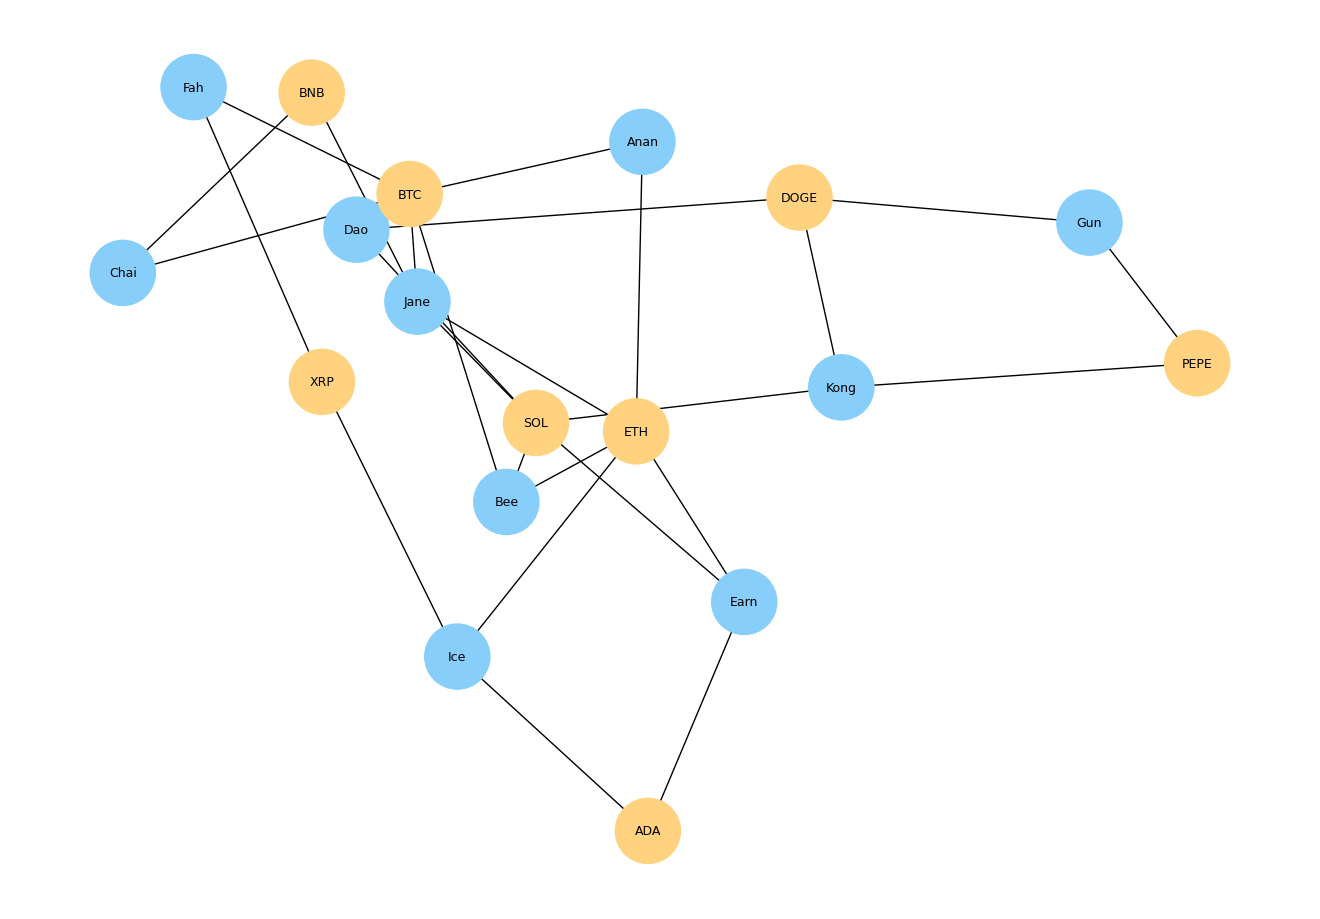

In [8]:
# ---------- วาดกราฟออกมาดูด้วยตา ----------

plt.figure(figsize=(13, 9))

# spring_layout จำลองแรงสปริง: โหนดที่เชื่อมกันจะถูกดึงเข้าหากัน
# k = ระยะห่างระหว่างโหนด (เพิ่มค่าเพราะมีโหนดถึง 18 ตัว ไม่งั้นทับกัน)
# seed = ล็อกผลให้ตำแหน่งเหมือนเดิมทุกครั้งที่รัน
pos = nx.spring_layout(
    G,
    k=0.8,
    seed=42
)

# ฟ้า = ผู้ใช้ / ส้ม = เหรียญ (ใช้ node_type ที่ติดไว้ตอนสร้างโหนด)
colors = [
    "#87CEFA" if G.nodes[n]["node_type"] == "user" else "#FFD27F"
    for n in G.nodes
]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=2200,
    font_size=9
)

plt.show()

คำถามแรก <br>



1. ถามว่า Anan ถือเหรียญอะไรบ้าง?

In [9]:
# G.neighbors(x) = โหนดที่ต่อกับ x โดยตรง หรือก็คือ "เดิน 1 ก้าว" (1 hop)
# เพื่อนบ้านของผู้ใช้ จึงเท่ากับเหรียญทั้งหมดที่เขาถือ

anan_coins = list(
    G.neighbors("Anan")
)

print(anan_coins)

['BTC', 'ETH']


ตรงนี้อธิบายได้ว่า Neighbor ของ Anan คือ Node ที่เชื่อมกับ Anan

คำถามที่ 2. หา User ที่ถือเหรียญเหมือน Anan <br>



Anan ถือ BTC ETH <br>



เราสามารถหาได้ว่าใครถือเหรียญเหล่านี้เหมือนกัน

In [10]:
# เดิน 2 hop: Anan -> เหรียญที่ถือ -> คนอื่นที่ถือเหรียญตัวเดียวกัน
# ผลที่ได้คือ "ผู้ใช้ที่มีความสนใจทับซ้อนกับ Anan"

for coin in G.neighbors("Anan"):          # hop 1: ไปที่เหรียญ

    print("Coin:", coin)

    for user in G.neighbors(coin):        # hop 2: ย้อนกลับไปหาคน

        if user != "Anan":                # ไม่นับตัวเอง
            print("  Similar user:", user)

Coin: BTC
  Similar user: Bee
  Similar user: Chai
  Similar user: Fah
  Similar user: Jane
Coin: ETH
  Similar user: Bee
  Similar user: Earn
  Similar user: Ice
  Similar user: Jane


**สร้าง Recommendation แบบง่าย**

```
แนวคิดคือ

Anan
 ↓
เหรียญที่ Anan ถือ
 ↓
User ที่ถือเหรียญเดียวกัน
 ↓
เหรียญอื่นที่ User เหล่านั้นถือ
 ↓
แนะนำให้ Anan
```

In [11]:
from collections import Counter


target_user = "Anan"

# Counter = dict ที่นับจำนวนให้อัตโนมัติ ใช้เก็บคะแนนของแต่ละเหรียญ
recommendations = Counter()


# เหรียญที่ Anan ถืออยู่แล้ว (ใช้ set เพราะต้องเช็ค in บ่อย ทำงานเร็วกว่า list)
held_coins = set(
    G.neighbors(target_user)
)


# hop 1: ดูเหรียญแต่ละตัวที่ Anan ถือ
for coin in held_coins:

    # hop 2: หา User ที่ถือเหรียญตัวเดียวกัน
    for similar_user in G.neighbors(coin):

        if similar_user == target_user:
            continue                      # กันไม่ให้วนกลับมาที่ตัวเอง

        # hop 3: ดูว่า User คนนั้นถือเหรียญอะไรอีก
        for other_coin in G.neighbors(similar_user):

            if other_coin not in held_coins:   # ตัดเหรียญที่ Anan มีแล้วออก

                recommendations[other_coin] += 1   # +1 ทุกครั้งที่เดินมาถึง


print(recommendations)

Counter({'SOL': 5, 'BNB': 3, 'XRP': 2, 'ADA': 2})


ผลที่ได้คือ `SOL 5, BNB 3, XRP 2, ADA 2, DOGE 1, PEPE 1`



SOL ได้ 5 คะแนน เพราะเดินจาก Anan ไปถึง SOL ได้ถึง 5 เส้นทาง

(ผ่าน BTC → Bee/Jane และ ETH → Bee/Earn/Jane)

ยิ่งคะแนนมาก แปลว่าเชื่อมโยงกันหลายเส้นทาง ไม่ใช่บังเอิญตรงกันแค่จุดเดียว

In [12]:
# นำไปสร้างเป็นฟังก์ชัน

In [13]:
from collections import Counter


def recommend_coins(G, target_user):
    """
    แนะนำเหรียญให้ target_user ด้วยการเดินกราฟ 3 hop

        target_user -> เหรียญที่ถือ -> คนอื่นที่ถือเหมือนกัน -> เหรียญใหม่

    คืนค่า: list ของ (เหรียญ, คะแนน) เรียงจากมากไปน้อย
    คะแนน = จำนวนเส้นทางที่เดินไปถึงเหรียญนั้นได้ ยิ่งมากยิ่งเกี่ยวข้องกันมาก
    """

    recommendations = Counter()

    # เหรียญที่ถืออยู่แล้ว เอาไว้ตัดออกจากผลแนะนำ
    held_coins = set(
        G.neighbors(target_user)
    )

    for coin in held_coins:                          # hop 1

        for similar_user in G.neighbors(coin):       # hop 2

            if similar_user == target_user:
                continue

            for other_coin in G.neighbors(similar_user):   # hop 3

                if other_coin not in held_coins:

                    recommendations[other_coin] += 1

    # most_common() เรียงลำดับตามคะแนนจากมากไปน้อยให้เลย
    return recommendations.most_common()

In [14]:
# เรียกใช้งานทีละคน
# ผลที่ได้: SOL 5 คะแนน เพราะเดินจาก Anan ไปถึง SOL ได้ถึง 5 เส้นทาง
#   ผ่าน BTC -> Bee, Jane
#   ผ่าน ETH -> Bee, Earn, Jane

result = recommend_coins(G, "Anan")
print(result)

[('SOL', 5), ('BNB', 3), ('XRP', 2), ('ADA', 2)]


In [15]:
# ดูผลของผู้ใช้ทุกคน
# สังเกต Gun ที่ถือแต่ DOGE กับ PEPE จะได้ผลแนะนำน้อยมาก
# เพราะเชื่อมกับส่วนอื่นของกราฟผ่าน Kong ทางเดียว (ปัญหา Cold Start)

for user in users:
    print(user, "->", recommend_coins(G, user))

Anan -> [('SOL', 5), ('BNB', 3), ('XRP', 2), ('ADA', 2)]
Bee -> [('BNB', 4), ('ADA', 3), ('XRP', 2), ('DOGE', 2), ('PEPE', 1)]
Chai -> [('ETH', 4), ('SOL', 3), ('XRP', 1)]
Dao -> [('ETH', 3), ('PEPE', 3), ('BTC', 2), ('ADA', 1), ('BNB', 1)]
Earn -> [('BTC', 5), ('DOGE', 2), ('BNB', 2), ('XRP', 2), ('PEPE', 1)]
Fah -> [('ETH', 4), ('SOL', 2), ('BNB', 2), ('ADA', 1)]
Gun -> [('SOL', 3)]
Ice -> [('BTC', 4), ('SOL', 4), ('BNB', 1)]
Jane -> [('ADA', 3), ('XRP', 2), ('DOGE', 2), ('PEPE', 1)]
Kong -> [('ETH', 3), ('BTC', 2), ('ADA', 1), ('BNB', 1)]


In [16]:
# ในระบบจริงจะไม่แสดงทั้งหมด แต่ตัดเอาเฉพาะอันดับต้น ๆ
TOP_N = 3

for user in users:
    top = recommend_coins(G, user)[:TOP_N]
    print(f"{user:5s} -> {top}")

Anan  -> [('SOL', 5), ('BNB', 3), ('XRP', 2)]
Bee   -> [('BNB', 4), ('ADA', 3), ('XRP', 2)]
Chai  -> [('ETH', 4), ('SOL', 3), ('XRP', 1)]
Dao   -> [('ETH', 3), ('PEPE', 3), ('BTC', 2)]
Earn  -> [('BTC', 5), ('DOGE', 2), ('BNB', 2)]
Fah   -> [('ETH', 4), ('SOL', 2), ('BNB', 2)]
Gun   -> [('SOL', 3)]
Ice   -> [('BTC', 4), ('SOL', 4), ('BNB', 1)]
Jane  -> [('ADA', 3), ('XRP', 2), ('DOGE', 2)]
Kong  -> [('ETH', 3), ('BTC', 2), ('ADA', 1)]


**ส่วนขยาย (ถ้าอยากได้มากกว่า Movie version)**







เพิ่ม Node ประเภทที่ 3 คือ `category` เช่น Layer1 / Exchange / Meme



แล้วเชื่อม `(Coin)-[:IN_CATEGORY]->(Category)`



ทำให้แนะนำได้แม้ User ไม่มีเพื่อนที่พอร์ตซ้ำกันเลย (แก้ปัญหา Cold Start)

In [18]:
# ---------- Node ชนิดที่ 3: หมวดหมู่ของเหรียญ ----------
categories = {
    "BTC": "Layer1",
    "ETH": "Layer1",
    "SOL": "Layer1",
    "ADA": "Layer1",
    "BNB": "Exchange",
    "XRP": "Payment",
    "DOGE": "Meme",
    "PEPE": "Meme"
}

# เชื่อม (Coin)-[:IN_CATEGORY]->(Category)
for coin, cat in categories.items():

    G.add_node(cat, node_type="category")
    G.add_edge(coin, cat)


def recommend_by_category(G, target_user):
    """
    แนะนำโดยไม่ต้องพึ่งผู้ใช้คนอื่นเลย เดินแค่

        target_user -> เหรียญที่ถือ -> หมวดหมู่ -> เหรียญอื่นในหมวดเดียวกัน

    ใช้แก้ปัญหา Cold Start: ผู้ใช้ใหม่ที่ยังไม่มีใครถือเหรียญซ้ำกัน
    """

    scores = Counter()

    # เพื่อนบ้านของผู้ใช้ตอนนี้มีทั้งเหรียญและหมวดหมู่ปนกัน
    # จึงต้องกรองเอาเฉพาะ node_type == "coin"
    held_coins = set(
        n for n in G.neighbors(target_user)
        if G.nodes[n]["node_type"] == "coin"
    )

    for coin in held_coins:

        for cat in G.neighbors(coin):

            # เพื่อนบ้านของเหรียญมีทั้ง "คน" และ "หมวดหมู่"
            # บรรทัดนี้กรองให้เหลือเฉพาะหมวดหมู่ ถ้าไม่มีจะเดินไปหาคนแทน
            if G.nodes[cat]["node_type"] != "category":
                continue

            for other_coin in G.neighbors(cat):

                if other_coin not in held_coins:
                    scores[other_coin] += 1

    return scores.most_common()


print(recommend_by_category(G, "Anan"))

[('SOL', 2), ('ADA', 2)]


Recommender System แบบ Graph ไม่ได้มองเพียงว่า “เหรียญไหนดี” แต่ดูว่า “ผู้ใช้คนนี้เชื่อมโยงกับผู้ใช้และเหรียญอื่นอย่างไร”